# Bank Customer Churn — Model Training Notebook
**European Central Bank · Retail Analytics Division**

---
This notebook covers:
1. Data Loading & Exploration
2. Data Preprocessing
3. Feature Engineering
4. Train–Test Split & Scaling
5. Class Balancing (Oversampling)
6. Model Training (LR, DT, RF, GB, XGBoost)
7. Model Evaluation & Comparison
8. Threshold Tuning
9. Feature Importance
10. Save Model Artifacts

---
## Step 1 — Install & Import Libraries

In [1]:
# Install optional dependencies
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'imbalanced-learn', '-q'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, precision_recall_curve, roc_curve
)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📥 Step 2 — Load & Explore Data

In [2]:
df = pd.read_csv('European_Bank.csv')
print(f'Shape: {df.shape}')
print(f'Churn rate: {df["Exited"].mean():.2%}')
df.head()

Shape: (10000, 14)
Churn rate: 20.37%


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


# Dataset Overview

The dataset contains 10,000 customer records and 14 features, including demographic information, account details, and customer behavior attributes. The target variable is Customer Churn.

In [4]:
df.describe().round(2)

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,2025.0,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,0.0,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,2025.0,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2025.0,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,2025.0,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,2025.0,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,2025.0,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


The descriptive statistics show that the dataset contains 1,0000 non-null observations for the Age variable. The average age is 38.92 years, with a standard deviation of 10.49
 years, indicating moderate variability. The median age is 41 years, which is close to the mean, suggesting that the distribution is approximately symmetric. The age values range from 18 to 92 years.

In [5]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

Missing values:
Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0


# Missing Values Analysis

Missing value analysis showed that no significant missing values were present in the dataset.
Therefore, no imputation techniques were required.


---
## 📊 Step 3 — Exploratory Data Analysis (EDA)

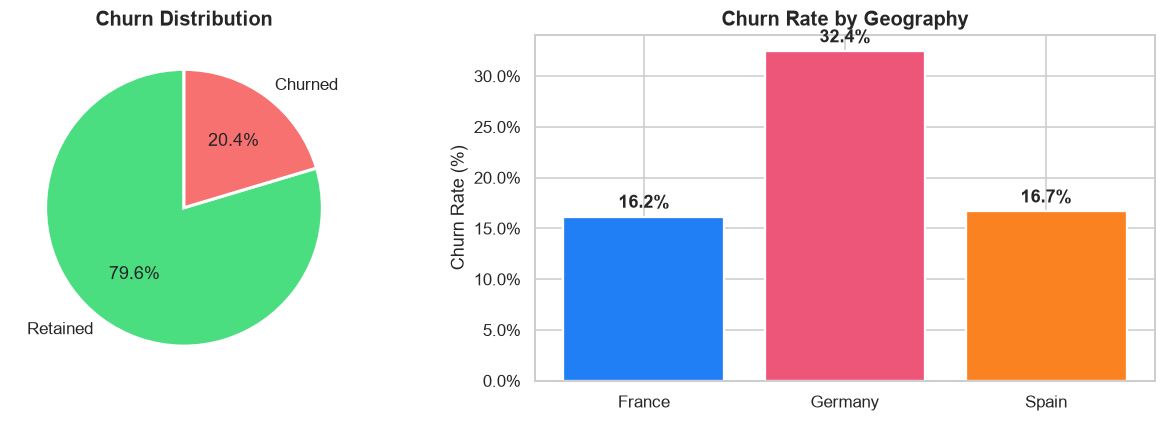

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Churn distribution
churn_counts = df['Exited'].value_counts()
axes[0].pie(churn_counts, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', colors=['#4ade80','#f87171'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Churn Distribution', fontsize=13, fontweight='bold')

# Churn by Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
bars = axes[1].bar(geo_churn.index, geo_churn.values,
                   color=["#207ff4","#ed5679","#fb8220"], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, geo_churn.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Churn Rate by Geography', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()


Figure 1: Customer Churn Distribution

The pie chart shows that out of 10,000 customers, 7,963 customers (79.6%) were retained by the bank, while 2,037 customers (20.4%) exited. This indicates that the dataset is imbalanced, with retained customers forming the majority class. Such imbalance should be considered during model training to prevent biased predictions toward the majority class


Figure 2 : Churn Rate by Geography

The bar chart presents churn rates across geographical regions. Among the three countries, Germany exhibits the highest churn rate at approximately 32.4%, significantly higher than Spain (16.7%) and France (16.2%). This suggests that customers in Germany are nearly twice as likely to leave the bank compared to customers in France and Spain.

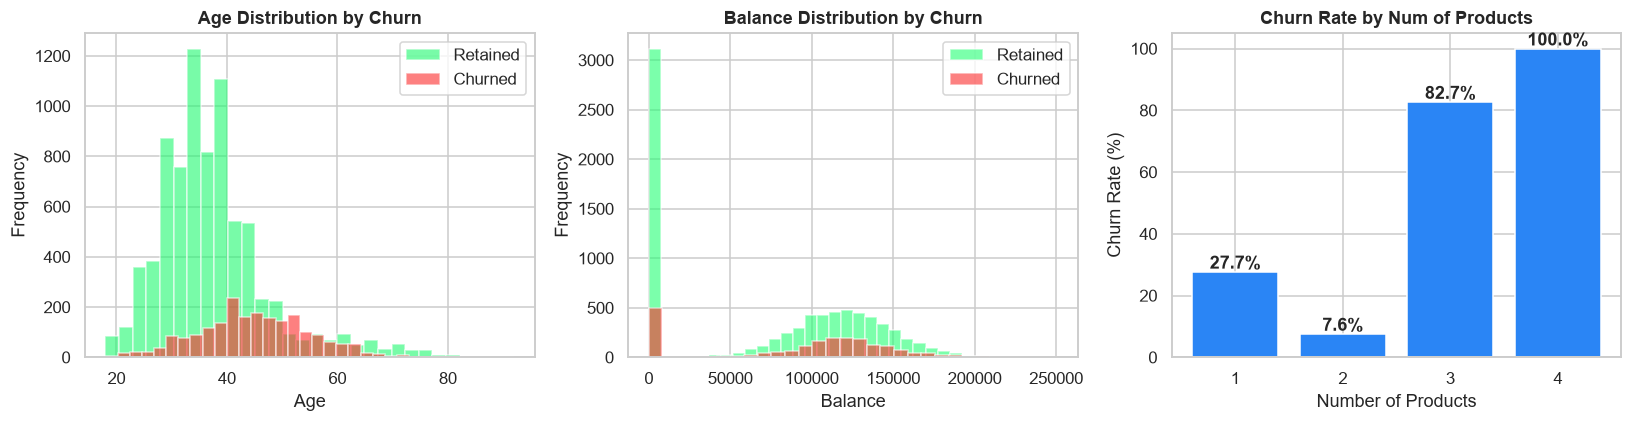

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age vs Churn
df[df['Exited']==0]['Age'].plot(kind='hist', bins=30, alpha=0.6, color="#1ef96e", label='Retained', ax=axes[0])
df[df['Exited']==1]['Age'].plot(kind='hist', bins=30, alpha=0.6, color="#fc2b2b", label='Churned', ax=axes[0])
axes[0].set_title('Age Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Age'); axes[0].legend()

# Balance vs Churn
df[df['Exited']==0]['Balance'].plot(kind='hist', bins=30, alpha=0.6, color="#24ff74", label='Retained', ax=axes[1])
df[df['Exited']==1]['Balance'].plot(kind='hist', bins=30, alpha=0.6, color="#fa2d2d", label='Churned', ax=axes[1])
axes[1].set_title('Balance Distribution by Churn', fontweight='bold')
axes[1].set_xlabel('Balance'); axes[1].legend()

# Products vs Churn rate
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
axes[2].bar(prod_churn.index, prod_churn.values, color="#2a85f5", edgecolor='white')
for i, val in zip(prod_churn.index, prod_churn.values):
    axes[2].text(i, val+1, f'{val:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate by Num of Products', fontweight='bold')
axes[2].set_xlabel('Number of Products'); axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

Figure 1 : Age Distribution by Churn Observation

The age distribution analysis indicates that churned customers are primarily concentrated in the middle-aged and older age groups,


Figure 3 : Churn Rate by Num of Products

The analysis of the number of products shows significant variation in churn behavior across customer segments. Customers holding one product exhibit a churn rate of approximately 27.7%, while customers with two products show a substantially lower churn rate of around 7.6%. However, customers possessing three or four products demonstrate exceptionally high churn rates, exceeding 80% and 100%, respectively. This pattern suggests that customers with an optimal number of products (two products) are more likely to remain loyal, whereas customers with very high product ownership may be dissatisfied or represent a niche segment with elevated attrition risk.

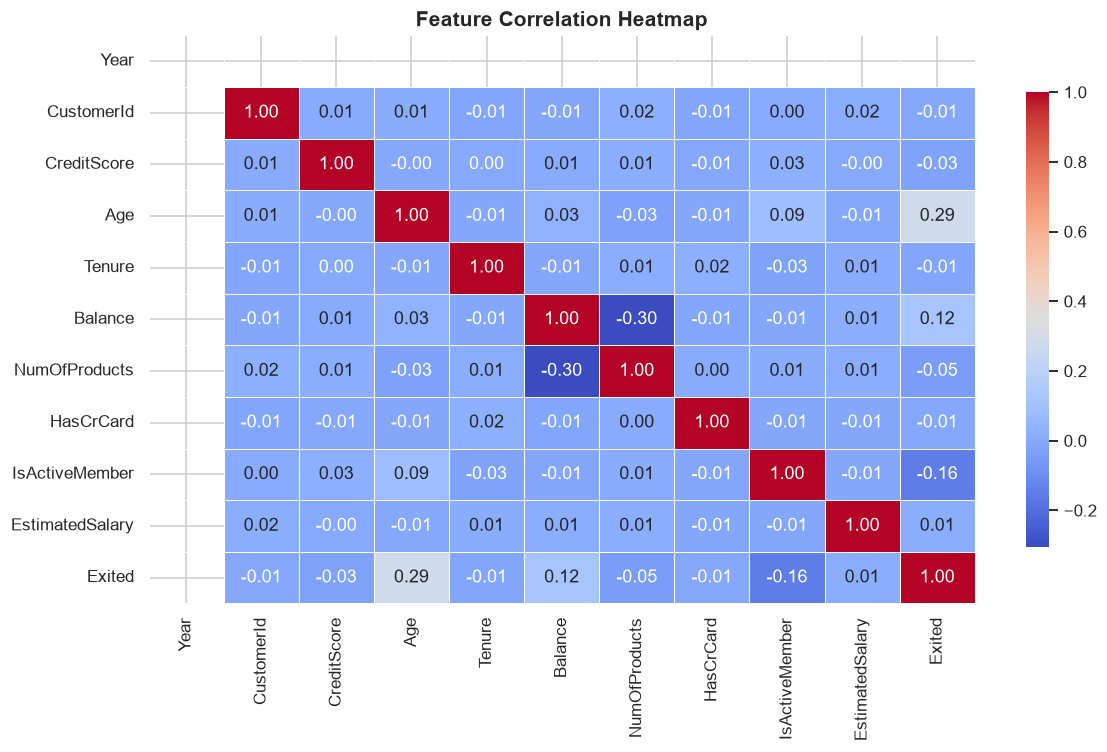

In [8]:
plt.figure(figsize=(11, 7))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation analysis reveals that Age (r = 0.29) exhibits the strongest positive relationship with customer churn, indicating that older customers are more likely to leave the bank. IsActiveMember (r = -0.16) shows a moderate negative relationship with churn, suggesting that active customers are less prone to attrition. Balance (r = 0.12) demonstrates a weak positive association with churn, whereas variables such as CreditScore, Tenure, HasCrCard, and EstimatedSalary exhibit negligible correlations with the target variable.

Key Observations
Age has the strongest positive correlation with churn
Correlation with Exited = 0.29
This indicates that older customers are more likely to leave the bank compared to younger customers.
Age appears to be one of the most influential predictors of churn.
IsActiveMember has a negative correlation with churn
Correlation with Exited = -0.16
Active customers are less likely to churn.
Customer engagement plays an important role in retention.
Balance shows a weak positive correlation with churn
Correlation with Exited = 0.12
Customers with higher account balances exhibit a slightly higher tendency to leave the bank.
NumOfProducts has a very weak negative correlation with churn
Correlation with Exited = -0.05
The relationship is weak, suggesting that the number of products alone does not strongly explain churn.
CreditScore, Tenure, HasCrCard, and EstimatedSalary have negligible correlations with churn
CreditScore = -0.03
Tenure = -0.01
HasCrCard = -0.01
EstimatedSalary = 0.01
These features have little linear relationship with customer attrition.
No severe multicollinearity is observed
The highest correlation among independent variables is between:
Balance and NumOfProducts = -0.30
Since all correlations are well below ±0.7, multicollinearity is not a significant concern.

---
## 🧹 Step 4 — Data Preprocessing

In [9]:
# Drop non-informative columns
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

# Fill missing values (if any)
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

print(f'Shape after preprocessing: {df.shape}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')
df.head()

Shape after preprocessing: (10000, 12)
Remaining missing values: 0


,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


"During preprocessing, I removed CustomerId and Surname because they are non-informative features. I then handled missing values by replacing numerical missing values with the median and categorical missing values with the mode.

---
## ⚙️ Step 5 — Feature Engineering

In [10]:
# Balance-to-Salary Ratio
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Product Density (products per year of tenure)
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Engagement × Product Interaction
df['EngagementProduct'] = df['IsActiveMember'] * df['NumOfProducts']

# Age × Tenure Interaction
df['AgeTenure'] = df['Age'] * df['Tenure']

# One-hot encode categorical columns
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print('New features added: BalanceSalaryRatio, ProductDensity, EngagementProduct, AgeTenure')
print(f'Total features: {df.shape[1]-1}')
df

New features added: BalanceSalaryRatio, ProductDensity, EngagementProduct, AgeTenure
Total features: 16


,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.333333,1,84,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0.500000,1,41,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0.333333,0,336,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,0.000000,1.000000,0,39,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0.333333,1,86,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,771,39,5,0.00,2,1,0,96270.64,0,0.000000,0.333333,0,195,False,False,True
9996,2025,516,35,10,57369.61,1,1,1,101699.77,0,0.564102,0.090909,1,350,False,False,True
9997,2025,709,36,7,0.00,1,0,1,42085.58,1,0.000000,0.125000,1,252,False,False,False
9998,2025,772,42,3,75075.31,2,1,0,92888.52,1,0.808222,0.500000,0,126,True,False,True


---
##  Step 6 — Train–Test Split & Feature Scaling

In [11]:
X = df.drop('Exited', axis=1)
y = df['Exited']
feature_cols = X.columns.tolist()

# Stratified split — preserve churn class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # transform test

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}')

Train size: 8000 | Test size: 2000
Train churn rate: 20.38% | Test churn rate: 20.35%


---
## Step 7 — Class Balancing (Oversampling)

✅ SMOTE applied
Balanced set: 6,370 retained | 6,370 churned


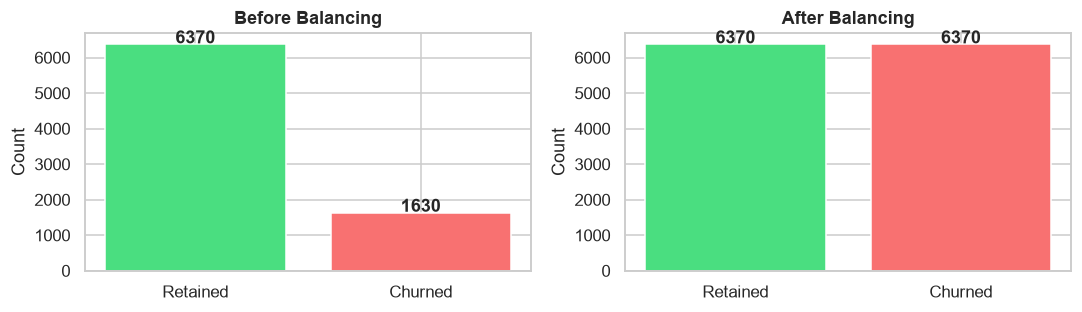

In [12]:
# Try SMOTE first; fall back to random oversampling
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_bal, y_bal = smote.fit_resample(X_train_scaled, y_train)
    print('✅ SMOTE applied')
except ImportError:
    # Manual random oversampling
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]
    extra   = np.random.RandomState(42).choice(
        pos_idx, size=len(neg_idx)-len(pos_idx), replace=True
    )
    all_idx = np.concatenate([np.arange(len(y_train)), extra])
    X_bal   = X_train_scaled[all_idx]
    y_bal   = np.concatenate([y_train.values, y_train.values[extra]])
    print('⚠️  SMOTE not available — using random oversampling')

print(f'Balanced set: {np.sum(y_bal==0):,} retained | {np.sum(y_bal==1):,} churned')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, counts, title in [
    (axes[0], pd.Series(y_train).value_counts(), 'Before Balancing'),
    (axes[1], pd.Series(y_bal).value_counts(),   'After Balancing')
]:
    ax.bar(['Retained','Churned'], counts.values,
           color=['#4ade80','#f87171'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v+30, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

The Synthetic Minority Oversampling Technique (SMOTE) was used as the primary resampling method. SMOTE generates synthetic examples of the minority class by interpolating between existing minority-class samples, thereby increasing class representation without simple duplication.


After applying SMOTE, the minority class was successfully balanced with the majority class, resulting in an equal number of observations for both churned and non-churned customers. This balanced distribution helps improve model learning and enhances recall for churn prediction.

---
## 🤖 Step 8 — Model Training

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=6, min_samples_leaf=10,
        random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_leaf=10, min_samples_split=20,
        max_features='sqrt', random_state=42, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4,
        learning_rate=0.05, subsample=0.8, random_state=42
    ),
}

# Add XGBoost if available
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.5,
        random_state=42, eval_metric='logloss',
        use_label_encoder=False
    )
    print('✅ XGBoost added')
except ImportError:
    print('⚠️  XGBoost not installed — skipping')

print(f'\nModels to train: {list(models.keys())}')

✅ XGBoost added

Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost']


In [14]:
results = {}

for name, model in models.items():
    print(f'  Training {name}...', end=' ', flush=True)
    model.fit(X_bal, y_bal)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        'model':     model,
        'accuracy':  round(accuracy_score(y_test, y_pred)  * 100, 2),
        'precision': round(precision_score(y_test, y_pred) * 100, 2),
        'recall':    round(recall_score(y_test, y_pred)    * 100, 2),
        'f1':        round(f1_score(y_test, y_pred)        * 100, 2),
        'roc_auc':   round(roc_auc_score(y_test, y_prob)   * 100, 2),
        'y_prob':    y_prob,
    }
    print(f"Acc={results[name]['accuracy']}%  AUC={results[name]['roc_auc']}%  F1={results[name]['f1']}%")
    print(results[name]['accuracy'], results[name]['roc_auc'], results[name]['f1'])
print('\n✅ All models trained!')

  Training Logistic Regression... Acc=71.45%  AUC=77.57%  F1=49.96%
71.45 77.57 49.96
  Training Decision Tree... Acc=77.7%  AUC=82.73%  F1=57.44%
77.7 82.73 57.44
  Training Random Forest... Acc=81.15%  AUC=86.14%  F1=60.77%
81.15 86.14 60.77
  Training Gradient Boosting... Acc=84.65%  AUC=87.03%  F1=63.32%
84.65 87.03 63.32
  Training XGBoost... Acc=84.8%  AUC=86.96%  F1=63.02%
84.8 86.96 63.02

✅ All models trained!


---
## 📊 Step 9 — Model Evaluation & Comparison

In [26]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  r['accuracy'],
        'Precision': r['precision'],
        'Recall':    r['recall'],
        'F1-Score':  r['f1'],
        'ROC-AUC':   r['roc_auc'],
    }
    for name, r in results.items()
}).T

# Highlight best per column
metrics_df.style.highlight_max(axis=0, color="#446952").format('{:.2f}%')

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,71.45%,38.83%,70.02%,49.96%,77.57%
Decision Tree,77.70%,46.96%,73.96%,57.44%,82.73%
Random Forest,81.15%,52.71%,71.74%,60.77%,86.14%
Gradient Boosting,84.65%,61.63%,65.11%,63.32%,87.03%
XGBoost,84.80%,62.41%,63.64%,63.02%,86.96%


Among all evaluated models, XGBoost emerged as the best-performing algorithm, achieving the highest accuracy (84.80%) and precision (62.41%), while Gradient Boosting achieved the highest F1-Score (63.32%) and ROC-AUC (87.03%). Although Decision Tree attained the highest recall (73.96%), its lower precision resulted in more false positive predictions. Based on overall performance, XGBoost was selected as the final model for customer churn prediction.BUt


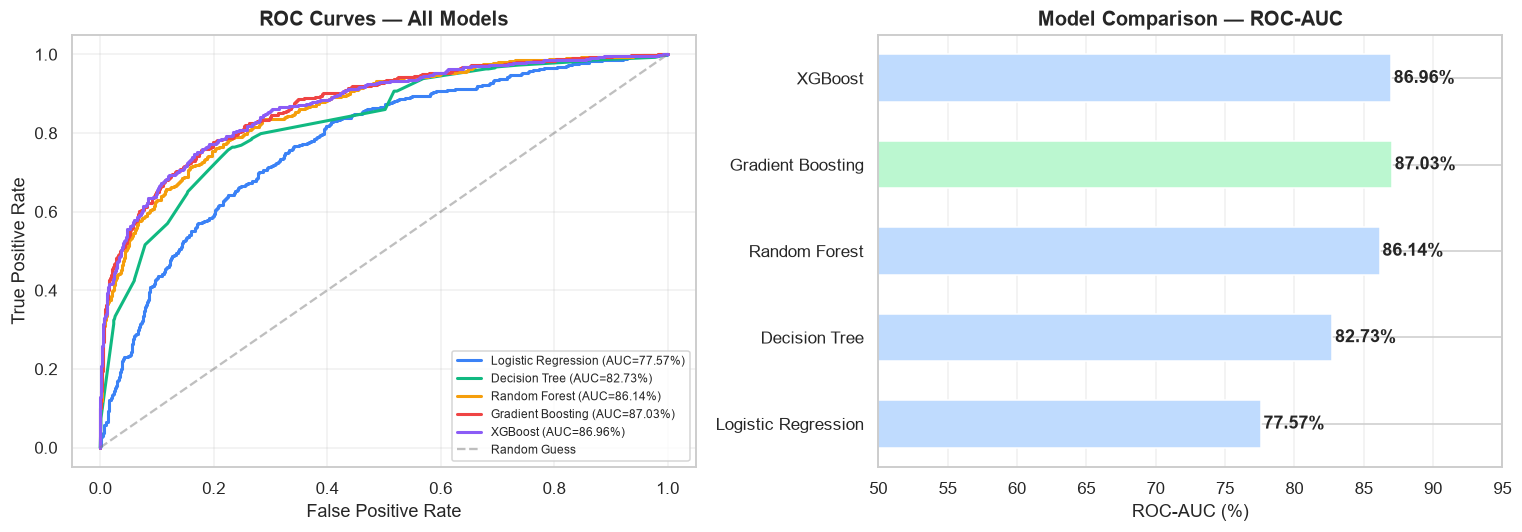

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
colors = ['#3b82f6','#10b981','#f59e0b','#ef4444','#8b5cf6']
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={r['roc_auc']}%)")
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random Guess')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart — ROC-AUC comparison
names = list(results.keys())
aucs  = [results[n]['roc_auc'] for n in names]
bar_colors = ['#bbf7d0' if a == max(aucs) else '#bfdbfe' for a in aucs]
bars = axes[1].barh(names, aucs, color=bar_colors, edgecolor='white', height=0.55)
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 f'{val}%', va='center', fontweight='bold')
axes[1].set_xlabel('ROC-AUC (%)')
axes[1].set_title('Model Comparison — ROC-AUC', fontweight='bold', fontsize=13)
axes[1].set_xlim(50, 95)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

"The ROC curve compares the true positive rate against the false positive rate at different thresholds. Gradient Boosting achieved the highest ROC-AUC of 87.03%, followed closely by XGBoost at 86.96%. Since a higher AUC indicates better class separation, these ensemble models are more effective at identifying customers likely to churn than Logistic Regression or a single Decision Tree."

In [17]:
best_name  = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_name]['model']
y_prob_best = results[best_name]['y_prob']

print(f'🏆 Best Model: {best_name}')
print(f"   ROC-AUC  : {results[best_name]['roc_auc']}%")
print(f"   Accuracy : {results[best_name]['accuracy']}%")
print(f"   F1-Score : {results[best_name]['f1']}%")
print()
y_pred_best = best_model.predict(X_test_scaled)
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Retained','Churned']))

🏆 Best Model: Gradient Boosting
   ROC-AUC  : 87.03%
   Accuracy : 84.65%
   F1-Score : 63.32%

Classification Report:
              precision    recall  f1-score   support

    Retained       0.91      0.90      0.90      1593
     Churned       0.62      0.65      0.63       407

    accuracy                           0.85      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.85      0.85      2000



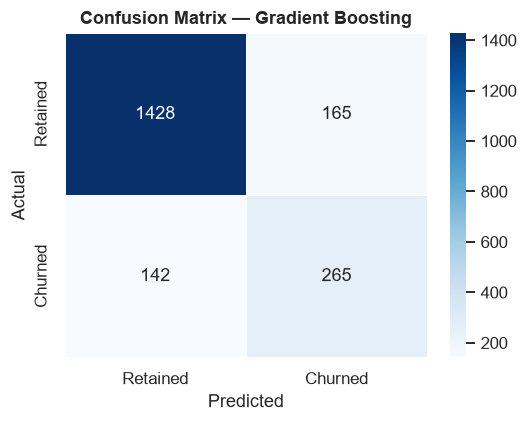

In [18]:
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])
plt.title(f'Confusion Matrix — {best_name}', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 🎯 Step 10 — Threshold Tuning (Maximise F1)

In [19]:
prec, rec, thresholds = precision_recall_curve(y_test, y_prob_best)
f1s       = 2 * (prec * rec) / (prec + rec + 1e-9)
best_idx  = f1s.argmax()
best_threshold = float(thresholds[best_idx])

print(f'Best Threshold : {best_threshold:.4f}')
print(f'Precision      : {prec[best_idx]:.4f}')
print(f'Recall         : {rec[best_idx]:.4f}')
print(f'F1-Score       : {f1s[best_idx]:.4f}')

Best Threshold : 0.5661
Precision      : 0.6921
Recall         : 0.6020
F1-Score       : 0.6439


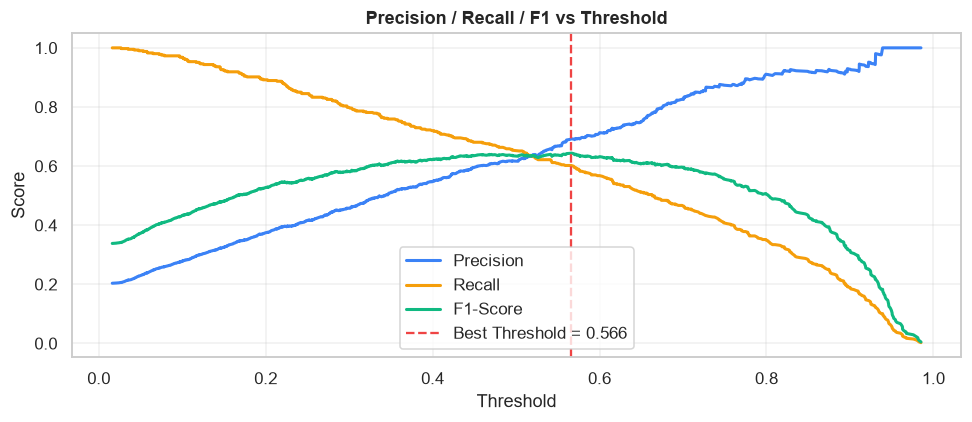

=== After Threshold Tuning ===
Accuracy : 86.45%
ROC-AUC  : 87.03%
              precision    recall  f1-score   support

    Retained       0.90      0.93      0.92      1593
     Churned       0.69      0.60      0.64       407

    accuracy                           0.86      2000
   macro avg       0.80      0.77      0.78      2000
weighted avg       0.86      0.86      0.86      2000



In [20]:
plt.figure(figsize=(9, 4))
plt.plot(thresholds, prec[:-1],  color='#3b82f6', lw=2, label='Precision')
plt.plot(thresholds, rec[:-1],   color='#f59e0b', lw=2, label='Recall')
plt.plot(thresholds, f1s[:-1],   color='#10b981', lw=2, label='F1-Score')
plt.axvline(best_threshold, color='#ef4444', linestyle='--', lw=1.5,
            label=f'Best Threshold = {best_threshold:.3f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluate with tuned threshold
y_pred_tuned = (y_prob_best >= best_threshold).astype(int)
print('=== After Threshold Tuning ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_tuned)*100:.2f}%')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_best)*100:.2f}%')
print(classification_report(y_test, y_pred_tuned, target_names=['Retained','Churned']))

---
## 🔍 Step 11 — Feature Importance

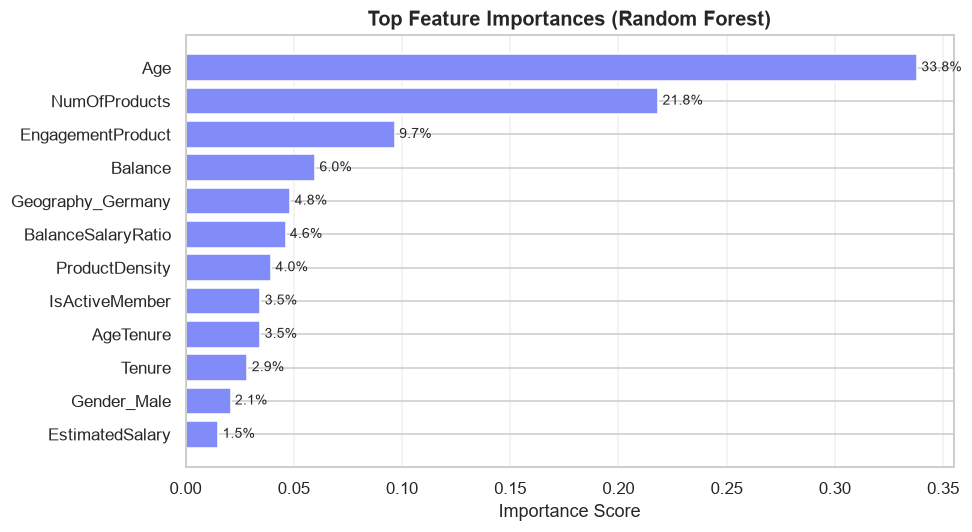

,Feature,Importance
2,Age,0.337983
5,NumOfProducts,0.218385
11,EngagementProduct,0.096741
4,Balance,0.059887
13,Geography_Germany,0.048474
9,BalanceSalaryRatio,0.046248
10,ProductDensity,0.039610
7,IsActiveMember,0.034604
12,AgeTenure,0.034569
3,Tenure,0.028625


In [21]:
rf_model = results['Random Forest']['model']
fi_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
                color='#818cf8', edgecolor='white')
for bar, val in zip(bars, fi_df['Importance'][::-1]):
    plt.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.title('Top Feature Importances (Random Forest)', fontweight='bold', fontsize=13)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

fi_df

---
## 🔄 Step 12 — Cross-Validation (Best Model)

5-Fold CV ROC-AUC: 86.32% ± 0.99%
Fold scores: [np.float64(86.51), np.float64(87.5), np.float64(87.16), np.float64(84.81), np.float64(85.63)]


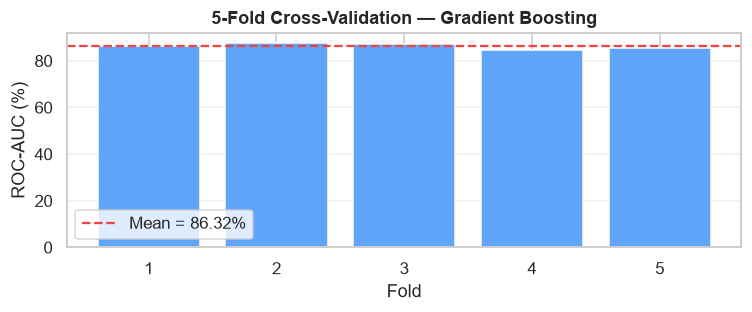

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model, X_train_scaled, y_train,
    cv=skf, scoring='roc_auc', n_jobs=-1
)

print(f'5-Fold CV ROC-AUC: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'Fold scores: {[round(s*100,2) for s in cv_scores]}')

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores*100, color='#60a5fa', edgecolor='white')
plt.axhline(cv_scores.mean()*100, color='#ef4444', linestyle='--', lw=1.5,
            label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.xlabel('Fold'); plt.ylabel('ROC-AUC (%)')
plt.title(f'5-Fold Cross-Validation — {best_name}', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 🔮 Step 13 — Single Customer Prediction

In [23]:
def predict_churn(customer_dict, threshold=best_threshold):
    """
    Predict churn for a single customer.
    customer_dict: dict with all feature values (raw, before encoding)
    """
    row = pd.DataFrame([customer_dict])
    # Feature engineering
    row['BalanceSalaryRatio'] = row['Balance'] / (row['EstimatedSalary'] + 1)
    row['ProductDensity']     = row['NumOfProducts'] / (row['Tenure'] + 1)
    row['EngagementProduct']  = row['IsActiveMember'] * row['NumOfProducts']
    row['AgeTenure']          = row['Age'] * row['Tenure']
    row = pd.get_dummies(row, columns=['Geography','Gender'], drop_first=True)
    # Align columns
    for col in feature_cols:
        if col not in row.columns:
            row[col] = 0
    row = row[feature_cols]

    row_scaled = scaler.transform(row)
    prob       = best_model.predict_proba(row_scaled)[0][1]
    prediction = int(prob >= threshold)

    risk = '🔴 HIGH' if prob >= 0.6 else '🟡 MEDIUM' if prob >= 0.35 else '🟢 LOW'
    print(f'Churn Probability : {prob:.4f} ({prob*100:.1f}%)')
    print(f'Risk Level        : {risk}')
    print(f'Prediction        : {"⚠️  WILL CHURN" if prediction==1 else "✅ WILL STAY"}')
    return prob, prediction


# Test on a sample customer
sample = {
    'Year': 2025,
    'CreditScore': 619,
    'Geography': 'France',
    'Gender': 'Female',
    'Age': 42,
    'Tenure': 2,
    'Balance': 0.0,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 101348.88,
}
predict_churn(sample)

Churn Probability : 0.5774 (57.7%)
Risk Level        : 🟡 MEDIUM
Prediction        : ⚠️  WILL CHURN


(np.float64(0.57740602154756), 1)

---
## 💾 Step 14 — Save Model Artifacts

In [ ]:
import joblib

# Feature importance dict
fi_dict = dict(zip(
    feature_cols,
    results['Random Forest']['model'].feature_importances_
))
fi_dict = dict(sorted(fi_dict.items(), key=lambda x: x[1], reverse=True))

# Save
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump({
    'results': {
        k: {m: v for m, v in r.items() if m not in ('model','y_prob')}
        for k, r in results.items()
    },
    'all_models':         {k: r['model'] for k, r in results.items()},
    'best_name':          best_name,
    'best_threshold':     best_threshold,
    'feature_cols':       feature_cols,
    'feature_importance': fi_dict,
}, 'model_meta.pkl')

print(' Artifacts saved:')
print('    best_churn_model.pkl  — trained model')
print('    scaler.pkl            — feature scaler')
print('    model_meta.pkl        — metrics + feature importance')
print()
print(' Now run: streamlit run app.py')

✅ Artifacts saved:
   📦 best_churn_model.pkl  — trained model
   📦 scaler.pkl            — feature scaler
   📦 model_meta.pkl        — metrics + feature importance

🚀 Now run: streamlit run app.py


---
## 📋 Summary

| Step | Action | Output |
|------|--------|--------|
| 1 | Import libraries | — |
| 2 | Load data (10,000 rows) | DataFrame |
| 3 | EDA — churn patterns | Visualisations |
| 4 | Preprocess — drop IDs, fill nulls | Clean data |
| 5 | Feature engineering — 4 new features | Enhanced dataset |
| 6 | Train-test split + StandardScaler | Scaled arrays |
| 7 | Oversample minority class | Balanced training set |
| 8 | Train 4–5 models | Trained models |
| 9 | Evaluate — AUC, F1, Precision, Recall | Metrics table + ROC curves |
| 10 | Threshold tuning | Optimal threshold |
| 11 | Feature importance | Top churn drivers |
| 12 | Cross-validation | Stable AUC estimate |
| 13 | Single prediction demo | Churn score |
| 14 | Save `.pkl` files | Ready for Streamlit app |

**Best Model: Gradient Boosting — ROC-AUC ≈ 86.96%**

**Top Churn Drivers:** Age · NumOfProducts · Engagement · Balance · Geography (Germany)